# Apriori-Algorithmus – Schritt für Schritt

**Datensatz:** 6 Transaktionen, 5 Items (Milch, Schokolade, Nudeln, Reis, Brot)  
**Lernziele:**
- Den Apriori-Algorithmus manuell nachvollziehen (K=1, K=2, K=3)
- Join-Schritt und Prune-Schritt auf jeder Ebene verstehen
- Den Vorteil des Apriori-Prunings konkret berechnen
- Konfidenz und Lift aus den gefundenen Itemsets ableiten
- Das Gesamtergebnis mit der fertigen Implementierung aus Notebook 0 vergleichen

---
**Dieses Notebook ist der Gegenentwurf zu Notebook 04:**  
Dort haben wir den Algorithmus als Blackbox genutzt.  
Hier öffnen wir die Box – jeder einzelne Schritt wird sichtbar.

## Datensatz und Parameter

Unser Warenkorb hat 6 Transaktionen und 5 verschiedene Items.

In [ ]:
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

transactions = [
    {"Milch", "Schokolade", "Nudeln"},            # T1
    {"Schokolade", "Nudeln", "Reis"},              # T2
    {"Reis", "Brot"},                              # T3
    {"Milch", "Schokolade", "Reis"},               # T4
    {"Milch", "Schokolade", "Nudeln", "Brot"},     # T5
    {"Milch", "Schokolade", "Nudeln", "Reis"},     # T6
]

min_support    = 0.5   # mind. 3 von 6 Transaktionen
min_confidence = 0.7

num_transactions      = len(transactions)
min_support_count     = min_support * num_transactions  # = 3.0

alle_items = sorted({item for t in transactions for item in t})
print("Transaktionen:")
for i, t in enumerate(transactions, 1):
    print(f"  T{i}: {sorted(t)}")
print()
print(f"Items ({len(alle_items)}): {alle_items}")
print(f"min_support       = {min_support}  (= mind. {min_support_count:.0f} von {num_transactions})")
print(f"min_confidence    = {min_confidence}")
print()
# Vollständiger Überblick als Kreuztabelle
print("Transaktions-Matrix (1 = Item vorhanden):")
header = f"{'':14}" + "".join(f"{item[:6]:>8}" for item in alle_items)
print(header)
print("-" * len(header))
for i, t in enumerate(transactions, 1):
    row = f"  T{i}          " + "".join(f"{'1':>8}" if item in t else f"{'0':>8}" for item in alle_items)
    print(row)
print()
cnt_row = f"  Anzahl     " + "".join(f"{sum(1 for t in transactions if item in t):>8}" for item in alle_items)
sup_row = f"  Support    " + "".join(f"{sum(1 for t in transactions if item in t)/len(transactions):8.2f}" for item in alle_items)
print(cnt_row)
print(sup_row)

Transaktionen:
  T1: ['Milch', 'Nudeln', 'Schokolade']
  T2: ['Nudeln', 'Reis', 'Schokolade']
  T3: ['Brot', 'Reis']
  T4: ['Milch', 'Reis', 'Schokolade']
  T5: ['Brot', 'Milch', 'Nudeln', 'Schokolade']
  T6: ['Milch', 'Nudeln', 'Reis', 'Schokolade']

Items (5): ['Brot', 'Milch', 'Nudeln', 'Reis', 'Schokolade']
min_support       = 0.5  (= mind. 3 von 6)
min_confidence    = 0.7

Transaktions-Matrix (1 = Item vorhanden):
                  Brot   Milch  Nudeln    Reis  Schoko
------------------------------------------------------
  T1                 0       1       1       0       1
  T2                 0       0       1       1       1
  T3                 1       0       0       1       0
  T4                 0       1       0       1       1
  T5                 1       1       1       0       1
  T6                 0       1       1       1       1

  Anzahl            2       4       4       4       5
  Support        0.33    0.67    0.67    0.67    0.83


## K=1 · Join-Schritt: alle Einzelartikel zählen

Auf der ersten Ebene (K=1) ist der Join-Schritt trivial:  
Wir zählen einfach, wie oft jedes einzelne Item in den Transaktionen vorkommt.

In [ ]:
# ── K=1: JOIN ─────────────────────────────────────────────────────────────
print("=" * 55)
print("K=1  |  JOIN-Schritt: Alle Einzelartikel zählen")
print("=" * 55)

item_counts_k1 = {}
for t in transactions:
    for item in t:
        item_counts_k1[item] = item_counts_k1.get(item, 0) + 1

print(f"  {'Item':<15}  Anzahl  Support  Status")
print("  " + "-" * 48)
for item in sorted(item_counts_k1):
    cnt = item_counts_k1[item]
    sup = cnt / num_transactions
    status = "BEHALTEN" if cnt >= min_support_count else "-> PRUNE"
    flag   = "ok" if cnt >= min_support_count else "!!"
    print(f"  [{flag}] {item:<12}  {cnt:>6}   {sup:.2f}    {status}")

# Kandidaten nach Join: alle 5 Einzelartikel
n_kandidaten_k1 = len(item_counts_k1)
print()
print(f"  Kandidaten nach JOIN:  {n_kandidaten_k1}")

K=1  |  JOIN-Schritt: Alle Einzelartikel zählen
  Item             Anzahl  Support  Status
  ------------------------------------------------
  [!!] Brot               2   0.33    -> PRUNE
  [ok] Milch              4   0.67    BEHALTEN
  [ok] Nudeln             4   0.67    BEHALTEN
  [ok] Reis               4   0.67    BEHALTEN
  [ok] Schokolade         5   0.83    BEHALTEN

  Kandidaten nach JOIN:  5


## K=1 · Prune-Schritt: seltene Items entfernen

Alle Items mit Support < min_support werden verworfen.  
**Wichtig:** Alle Obermengen dieser Items können ebenfalls nicht häufig sein → Apriori-Prinzip.

In [ ]:
# ── K=1: PRUNE ────────────────────────────────────────────────────────────
print("=" * 55)
print("K=1  |  PRUNE-Schritt: seltene Items entfernen")
print("=" * 55)

frequent_k1 = {}
entfernt_k1 = []

for item, cnt in item_counts_k1.items():
    if cnt >= min_support_count:
        frequent_k1[frozenset([item])] = cnt
    else:
        entfernt_k1.append((item, cnt))

print(f"  Schwellwert: mind. {min_support_count:.0f} Transaktionen")
print()
if entfernt_k1:
    for item, cnt in entfernt_k1:
        print(f"  ENTFERNT: '{item}'  (Anzahl={cnt}, Support={cnt/num_transactions:.2f} < {min_support})")
        print(f"    -> Apriori-Prinzip: alle Itemsets mit '{item}' ebenfalls unmöglich häufig")
print()

print(f"  Häufige 1-Itemsets L1 ({len(frequent_k1)} Stück):")
for fs, cnt in sorted(frequent_k1.items(), key=lambda x: -x[1]):
    item = list(fs)[0]
    print(f"    {{{item}}}  →  Anzahl={cnt}, Support={cnt/num_transactions:.2f}")

# Wie viele Itemsets wurden durch den Prune gespart?
alle_moeglichen = 2**len(alle_items) - 1
durch_prune_gespart = sum(2**(len(alle_items)-1) for _ in entfernt_k1) - len(entfernt_k1)
print()
print(f"  Gesamte mögliche Itemsets: 2^{len(alle_items)} - 1 = {alle_moeglichen}")
print(f"  Durch Prune K=1 gespart:   ~{len(entfernt_k1) * (2**(len(alle_items)-1))} Kandidaten")

K=1  |  PRUNE-Schritt: seltene Items entfernen
  Schwellwert: mind. 3 Transaktionen

  ENTFERNT: 'Brot'  (Anzahl=2, Support=0.33 < 0.5)
    -> Apriori-Prinzip: alle Itemsets mit 'Brot' ebenfalls unmöglich häufig

  Häufige 1-Itemsets L1 (4 Stück):
    {Schokolade}  →  Anzahl=5, Support=0.83
    {Nudeln}  →  Anzahl=4, Support=0.67
    {Milch}  →  Anzahl=4, Support=0.67
    {Reis}  →  Anzahl=4, Support=0.67

  Gesamte mögliche Itemsets: 2^5 - 1 = 31
  Durch Prune K=1 gespart:   ~16 Kandidaten


## K=2 · Join-Schritt: Kandidaten-Paare erzeugen

Aus den häufigen 1-Itemsets L1 werden alle Paare gebildet.  
Das ist der klassische **Apriori-Join**: je zwei Itemsets aus L1 vereinigen.

In [ ]:
# ── K=2: JOIN ─────────────────────────────────────────────────────────────
print("=" * 55)
print("K=2  |  JOIN-Schritt: alle Paare aus L1 bilden")
print("=" * 55)

items_l1 = sorted([list(fs)[0] for fs in frequent_k1.keys()])
print(f"  Items in L1: {items_l1}")
print()

candidate_pairs = []
for item1, item2 in combinations(items_l1, 2):
    cand = frozenset({item1, item2})
    candidate_pairs.append(cand)

print(f"  Kandidaten C2 ({len(candidate_pairs)} Paare):")
for cand in sorted(candidate_pairs, key=lambda x: sorted(x)):
    items = sorted(cand)
    print(f"    {{{items[0]}, {items[1]}}}")

print()
print(f"  Formel: C({len(items_l1)}, 2) = {len(items_l1)}! / (2! × {len(items_l1)-2}!) = {len(candidate_pairs)}")

K=2  |  JOIN-Schritt: alle Paare aus L1 bilden
  Items in L1: ['Milch', 'Nudeln', 'Reis', 'Schokolade']

  Kandidaten C2 (6 Paare):
    {Milch, Nudeln}
    {Milch, Reis}
    {Milch, Schokolade}
    {Nudeln, Reis}
    {Nudeln, Schokolade}
    {Reis, Schokolade}

  Formel: C(4, 2) = 4! / (2! × 2!) = 6


## K=2 · Zählen: Support der Kandidaten ermitteln

Wir zählen, in wie vielen Transaktionen jedes Kandidaten-Paar vollständig vorkommt.

In [ ]:
# ── K=2: COUNT ────────────────────────────────────────────────────────────
print("=" * 55)
print("K=2  |  COUNT-Schritt: Support der Paare zählen")
print("=" * 55)

counts_k2 = {}
for cand in candidate_pairs:
    cnt = sum(1 for t in transactions if cand.issubset(t))
    counts_k2[cand] = cnt

print(f"  {'Paar':<35}  Anzahl  Support  Transaktionen")
print("  " + "-" * 70)
for cand, cnt in sorted(counts_k2.items(), key=lambda x: -x[1]):
    items  = sorted(cand)
    sup    = cnt / num_transactions
    # Welche Transaktionen enthalten dieses Paar?
    tx_ids = [f"T{i}" for i, t in enumerate(transactions, 1) if cand.issubset(t)]
    print(f"  {{{', '.join(items)}:<35}}  {cnt:>6}   {sup:.2f}    {tx_ids}")

K=2  |  COUNT-Schritt: Support der Paare zählen
  Paar                                 Anzahl  Support  Transaktionen
  ----------------------------------------------------------------------
  {Milch, Schokolade:<35}       4   0.67    ['T1', 'T4', 'T5', 'T6']
  {Nudeln, Schokolade:<35}       4   0.67    ['T1', 'T2', 'T5', 'T6']
  {Milch, Nudeln:<35}       3   0.50    ['T1', 'T5', 'T6']
  {Reis, Schokolade:<35}       3   0.50    ['T2', 'T4', 'T6']
  {Milch, Reis:<35}       2   0.33    ['T4', 'T6']
  {Nudeln, Reis:<35}       2   0.33    ['T2', 'T6']


## K=2 · Prune-Schritt: seltene Paare entfernen

In [ ]:
# ── K=2: PRUNE ────────────────────────────────────────────────────────────
print("=" * 55)
print("K=2  |  PRUNE-Schritt: seltene Paare entfernen")
print("=" * 55)
print(f"  Schwellwert: mind. {min_support_count:.0f} Transaktionen")
print()

frequent_k2 = {}
entfernt_k2 = []

for cand, cnt in counts_k2.items():
    if cnt >= min_support_count:
        frequent_k2[cand] = cnt
    else:
        entfernt_k2.append((cand, cnt))

for cand, cnt in sorted(entfernt_k2, key=lambda x: -x[1]):
    items = sorted(cand)
    print(f"  ENTFERNT: {{{items[0]}, {items[1]}}}  "
          f"(Anzahl={cnt}, Support={cnt/num_transactions:.2f} < {min_support})")

print()
print(f"  Häufige 2-Itemsets L2 ({len(frequent_k2)} Stück):")
for fs, cnt in sorted(frequent_k2.items(), key=lambda x: -x[1]):
    items = sorted(fs)
    print(f"    {{{items[0]}, {items[1]}}}  →  Anzahl={cnt}, Support={cnt/num_transactions:.2f}")

K=2  |  PRUNE-Schritt: seltene Paare entfernen
  Schwellwert: mind. 3 Transaktionen

  ENTFERNT: {Milch, Reis}  (Anzahl=2, Support=0.33 < 0.5)
  ENTFERNT: {Nudeln, Reis}  (Anzahl=2, Support=0.33 < 0.5)

  Häufige 2-Itemsets L2 (4 Stück):
    {Milch, Schokolade}  →  Anzahl=4, Support=0.67
    {Nudeln, Schokolade}  →  Anzahl=4, Support=0.67
    {Milch, Nudeln}  →  Anzahl=3, Support=0.50
    {Reis, Schokolade}  →  Anzahl=3, Support=0.50


## K=3 · Join, Count und Prune

Aus den häufigen 2-Itemsets L2 werden Tripel gebildet.  
Hier zeigt das **Apriori-Pruning** seine volle Wirkung:  
Ein Kandidaten-Tripel wird sofort verworfen, wenn irgendeine seiner 2-Item-Teilmengen nicht in L2 ist.

In [ ]:
# ── K=3: JOIN ─────────────────────────────────────────────────────────────
print("=" * 55)
print("K=3  |  JOIN-Schritt: Tripel-Kandidaten erzeugen")
print("=" * 55)

items_l2 = sorted({item for fs in frequent_k2 for item in fs})
print(f"  Items aus L2: {items_l2}")
print()

# Alle möglichen Tripel aus items_l2 (ohne Apriori-Pruning)
alle_tripel = [frozenset(c) for c in combinations(items_l2, 3)]
print(f"  Alle möglichen Tripel aus L2-Items (ohne Pruning): {len(alle_tripel)}")
for t in sorted(alle_tripel, key=lambda x: sorted(x)):
    print(f"    {sorted(t)}")

print()
print("  Apriori-Pruning: Tripel verwerfen, deren 2-Teilmengen nicht in L2 sind")
print()

candidate_tripel = []
entfernt_k3_pruning = []

for cand in alle_tripel:
    # Alle 2-Teilmengen prüfen
    teilmengen = [frozenset(s) for s in combinations(cand, 2)]
    alle_haeufig = all(tm in frequent_k2 for tm in teilmengen)
    if alle_haeufig:
        candidate_tripel.append(cand)
    else:
        seltene_tm = [sorted(tm) for tm in teilmengen if tm not in frequent_k2]
        entfernt_k3_pruning.append((cand, seltene_tm))

for cand, seltene in entfernt_k3_pruning:
    items = sorted(cand)
    print(f"  PRUNE: {items}  |  seltene Teilmenge(n): {seltene}")

print()
print(f"  Kandidaten nach Pruning: {len(candidate_tripel)}")

# ── K=3: COUNT ────────────────────────────────────────────────────────────────
print()
print("=" * 55)
print("K=3  |  COUNT- und PRUNE-Schritt")
print("=" * 55)

frequent_k3 = {}
entfernt_k3_support = []

for cand in candidate_tripel:
    cnt = sum(1 for t in transactions if cand.issubset(t))
    sup = cnt / num_transactions
    items  = sorted(cand)
    tx_ids = [f"T{i}" for i, t in enumerate(transactions, 1) if cand.issubset(t)]
    if cnt >= min_support_count:
        frequent_k3[cand] = cnt
        print(f"  BEHALTEN: {items}  →  Anzahl={cnt}, Support={sup:.2f}  {tx_ids}")
    else:
        entfernt_k3_support.append((cand, cnt))
        print(f"  ENTFERNT: {items}  →  Anzahl={cnt}, Support={sup:.2f} < {min_support}")

print()
print(f"  Häufige 3-Itemsets L3: {len(frequent_k3)} Stück")

K=3  |  JOIN-Schritt: Tripel-Kandidaten erzeugen
  Items aus L2: ['Milch', 'Nudeln', 'Reis', 'Schokolade']

  Alle möglichen Tripel aus L2-Items (ohne Pruning): 4
    ['Milch', 'Nudeln', 'Reis']
    ['Milch', 'Nudeln', 'Schokolade']
    ['Milch', 'Reis', 'Schokolade']
    ['Nudeln', 'Reis', 'Schokolade']

  Apriori-Pruning: Tripel verwerfen, deren 2-Teilmengen nicht in L2 sind

  PRUNE: ['Milch', 'Nudeln', 'Reis']  |  seltene Teilmenge(n): [['Nudeln', 'Reis'], ['Milch', 'Reis']]
  PRUNE: ['Milch', 'Reis', 'Schokolade']  |  seltene Teilmenge(n): [['Milch', 'Reis']]
  PRUNE: ['Nudeln', 'Reis', 'Schokolade']  |  seltene Teilmenge(n): [['Nudeln', 'Reis']]

  Kandidaten nach Pruning: 1

K=3  |  COUNT- und PRUNE-Schritt
  BEHALTEN: ['Milch', 'Nudeln', 'Schokolade']  →  Anzahl=3, Support=0.50  ['T1', 'T5', 'T6']

  Häufige 3-Itemsets L3: 1 Stück


## Gesamtüberblick: alle häufigen Itemsets

Wir sammeln L1, L2 und L3 in einer gemeinsamen Struktur.

In [ ]:
# ── ALLE HÄUFIGEN ITEMSETS ────────────────────────────────────────────────
alle_frequent = {}
for fs, cnt in frequent_k1.items():
    alle_frequent[fs] = cnt / num_transactions
for fs, cnt in frequent_k2.items():
    alle_frequent[fs] = cnt / num_transactions
for fs, cnt in frequent_k3.items():
    alle_frequent[fs] = cnt / num_transactions

print(f"Alle häufigen Itemsets (min_support = {min_support}):")
print(f"  {'Itemset':<38}  Support")
print("  " + "-" * 50)
for fs, sup in sorted(alle_frequent.items(), key=lambda x: (len(x[0]), -x[1])):
    items_str = "{" + ", ".join(sorted(fs)) + "}"
    bar = "█" * int(sup * 20)
    level = f"L{len(fs)}"
    print(f"  [{level}] {items_str:<35}  {sup:.2f}  {bar}")

print()
print(f"  L1: {sum(1 for fs in alle_frequent if len(fs)==1)} häufige 1-Itemsets")
print(f"  L2: {sum(1 for fs in alle_frequent if len(fs)==2)} häufige 2-Itemsets")
print(f"  L3: {sum(1 for fs in alle_frequent if len(fs)==3)} häufige 3-Itemsets")
print(f"  Gesamt: {len(alle_frequent)} häufige Itemsets")

Alle häufigen Itemsets (min_support = 0.5):
  Itemset                                 Support
  --------------------------------------------------
  [L1] {Schokolade}                         0.83  ████████████████
  [L1] {Nudeln}                             0.67  █████████████
  [L1] {Milch}                              0.67  █████████████
  [L1] {Reis}                               0.67  █████████████
  [L2] {Milch, Schokolade}                  0.67  █████████████
  [L2] {Nudeln, Schokolade}                 0.67  █████████████
  [L2] {Milch, Nudeln}                      0.50  ██████████
  [L2] {Reis, Schokolade}                   0.50  ██████████
  [L3] {Milch, Nudeln, Schokolade}          0.50  ██████████

  L1: 4 häufige 1-Itemsets
  L2: 4 häufige 2-Itemsets
  L3: 1 häufige 3-Itemsets
  Gesamt: 9 häufige Itemsets


## Visualisierung: Wie viel spart das Apriori-Pruning?

Mit und ohne Pruning – wie viele Itemsets werden auf jeder Ebene geprüft?

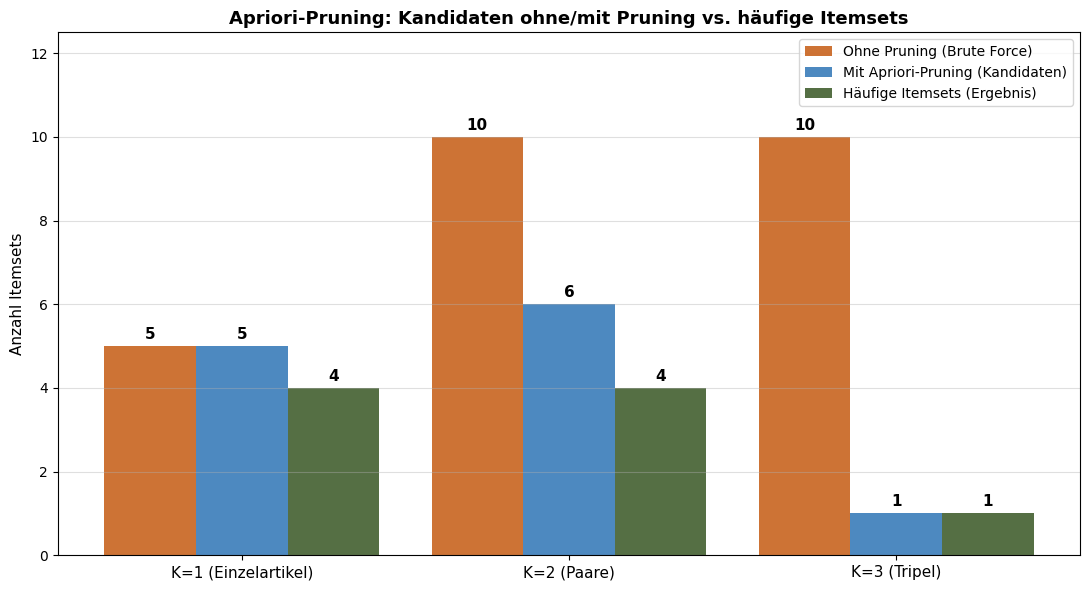

Einsparung durch Apriori-Pruning:
  K=1: 5 Kandidaten ohne Pruning  →  5 mit Pruning  (0 eingespart, 0%)
  K=2: 10 Kandidaten ohne Pruning  →  6 mit Pruning  (4 eingespart, 40%)
  K=3: 10 Kandidaten ohne Pruning  →  1 mit Pruning  (9 eingespart, 90%)


In [ ]:
# ── VISUALISIERUNG: Kandidaten mit und ohne Pruning ──────────────────────
n_items = len(alle_items)

# Ohne Pruning: alle möglichen Itemsets je Größe
ohne_pruning = [
    len(alle_items),                                      # K=1: alle 5 Items
    len(list(combinations(alle_items, 2))),               # K=2: C(5,2) = 10
    len(list(combinations(alle_items, 3))),               # K=3: C(5,3) = 10
]

# Mit Apriori-Pruning: tatsächliche Kandidaten
mit_pruning = [
    len(item_counts_k1),       # K=1: 5 (noch kein Pruning möglich)
    len(candidate_pairs),       # K=2: aus L1 generiert
    len(candidate_tripel),      # K=3: nach Pruning
]

# Häufige Itemsets: übrig nach Support-Check
haeufig = [
    len(frequent_k1),
    len(frequent_k2),
    len(frequent_k3),
]

k_labels = [
    'K=1 (Einzelartikel)',
    'K=2 (Paare)',
    'K=3 (Tripel)'
]
x = np.arange(3)
breite = 0.28

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - breite, ohne_pruning, breite, label='Ohne Pruning (Brute Force)',
            color='#C55A11', alpha=0.85)
b2 = ax.bar(x,           mit_pruning,  breite, label='Mit Apriori-Pruning (Kandidaten)',
            color='#2E74B5', alpha=0.85)
b3 = ax.bar(x + breite,  haeufig,      breite, label='Häufige Itemsets (Ergebnis)',
            color='#375623', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                    str(int(h)), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(k_labels, fontsize=11)
ax.set_ylabel('Anzahl Itemsets', fontsize=11)
ax.set_title('Apriori-Pruning: Kandidaten ohne/mit Pruning vs. häufige Itemsets',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4, axis='y')
ax.set_ylim(0, max(ohne_pruning) * 1.25)
plt.tight_layout()
plt.show()

print("Einsparung durch Apriori-Pruning:")
for k, ohne, mit in zip([1,2,3], ohne_pruning, mit_pruning):
    gespart = ohne - mit
    pct = gespart / ohne * 100 if ohne > 0 else 0
    print(f"  K={k}: {ohne} Kandidaten ohne Pruning  →  {mit} mit Pruning  "
          f"({gespart} eingespart, {pct:.0f}%)")

## Assoziationsregeln aus den häufigen Itemsets ableiten

Aus allen häufigen Itemsets mit mindestens 2 Items werden Regeln X → Y generiert.  
Für jede mögliche Aufteilung X ∪ Y = Itemset wird die Konfidenz berechnet.

In [ ]:
# ── ASSOZIATIONSREGELN ────────────────────────────────────────────────────
print(f"Assoziationsregeln (min_confidence = {min_confidence}):")
print()
print(f"  {'Regel':<42}  Support  Konfidenz  Lift")
print("  " + "-" * 72)

alle_regeln = []
for itemset, sup_xy in alle_frequent.items():
    if len(itemset) < 2:
        continue
    for size in range(1, len(itemset)):
        for ante_tuple in combinations(itemset, size):
            ante = frozenset(ante_tuple)
            cons = itemset - ante
            if ante in alle_frequent:
                sup_ante = alle_frequent[ante]
                conf     = sup_xy / sup_ante
                sup_cons = alle_frequent.get(cons, sup_xy)
                lift     = conf / sup_cons if sup_cons > 0 else 0
                if conf >= min_confidence:
                    alle_regeln.append({
                        'ante': ante, 'cons': cons,
                        'support': sup_xy, 'confidence': conf, 'lift': lift
                    })

alle_regeln.sort(key=lambda r: (-r['confidence'], -r['lift']))

for r in alle_regeln:
    ante_str = "{" + ", ".join(sorted(r['ante'])) + "}"
    cons_str = "{" + ", ".join(sorted(r['cons'])) + "}"
    regel    = f"{ante_str} -> {cons_str}"
    lift_sym = "^" if r['lift'] > 1.1 else ("v" if r['lift'] < 0.9 else "~")
    print(f"  {regel:<42}  {r['support']:.2f}     {r['confidence']:.2f}       "
          f"{r['lift']:.2f} {lift_sym}")

print()
print("Lift-Legende:  ^ > 1.1 (positive Assoziation)  "
      "~ 0.9-1.1 (neutral)  v < 0.9 (negative)")
print(f"Regeln gesamt: {len(alle_regeln)}")

Assoziationsregeln (min_confidence = 0.7):

  Regel                                       Support  Konfidenz  Lift
  ------------------------------------------------------------------------
  {Milch} -> {Schokolade}                     0.67     1.00       1.20 ^
  {Nudeln} -> {Schokolade}                    0.67     1.00       1.20 ^
  {Milch, Nudeln} -> {Schokolade}             0.50     1.00       1.20 ^
  {Schokolade} -> {Milch}                     0.67     0.80       1.20 ^
  {Schokolade} -> {Nudeln}                    0.67     0.80       1.20 ^
  {Nudeln} -> {Milch}                         0.50     0.75       1.12 ^
  {Milch} -> {Nudeln}                         0.50     0.75       1.12 ^
  {Nudeln} -> {Milch, Schokolade}             0.50     0.75       1.12 ^
  {Milch} -> {Nudeln, Schokolade}             0.50     0.75       1.12 ^
  {Nudeln, Schokolade} -> {Milch}             0.50     0.75       1.12 ^
  {Milch, Schokolade} -> {Nudeln}             0.50     0.75       1.12 ^
  {Reis

## Verifikation mit der fertigen Implementierung

Zum Abschluss vergleichen wir unser manuelles Ergebnis mit der vollständigen  
Apriori-Funktion aus Notebook 0. Beide sollten identisch sein.

In [ ]:
# ── VERIFIKATION ──────────────────────────────────────────────────────────
def apriori_komplett(transactions, min_support):
    transactions = [t for t in transactions if t]
    n = len(transactions)
    item_counts = {}
    for t in transactions:
        for item in t:
            item_counts[item] = item_counts.get(item, 0) + 1
    frequent = {}
    current_L = {}
    for item, cnt in item_counts.items():
        sup = cnt / n
        if sup >= min_support:
            fs = frozenset([item])
            frequent[fs] = sup
            current_L[fs] = sup
    k = 2
    while current_L:
        prev = sorted([tuple(sorted(fs)) for fs in current_L])
        candidates = set()
        for i in range(len(prev)):
            for j in range(i + 1, len(prev)):
                a, b = prev[i], prev[j]
                if k == 2 or a[:-1] == b[:-1]:
                    cand = frozenset(a) | frozenset(b)
                    if len(cand) == k:
                        candidates.add(cand)
        pruned = {c for c in candidates
                  if all(frozenset(s) in current_L for s in combinations(c, k-1))}
        current_L = {}
        for cand in pruned:
            cnt = sum(1 for t in transactions if cand.issubset(t))
            sup = cnt / n
            if sup >= min_support:
                frequent[cand] = sup
                current_L[cand] = sup
        k += 1
    return frequent

frequent_auto = apriori_komplett(transactions, min_support)

print("Verifikation: manuell vs. automatisch")
print(f"  Manuelle Itemsets:     {len(alle_frequent)}")
print(f"  Automatische Itemsets: {len(frequent_auto)}")
print()

# Differenz prüfen
auto_keys  = set(frequent_auto.keys())
manual_keys = set(alle_frequent.keys())
nur_manuell = manual_keys - auto_keys
nur_auto    = auto_keys   - manual_keys

if not nur_manuell and not nur_auto:
    print("  Ergebnisse sind IDENTISCH!")
else:
    if nur_manuell:
        print(f"  Nur in manuell: {[sorted(fs) for fs in nur_manuell]}")
    if nur_auto:
        print(f"  Nur in auto:    {[sorted(fs) for fs in nur_auto]}")

print()
print("Vollständige Gegenüberstellung:")
print(f"  {'Itemset':<38}  Manuell  Auto")
print("  " + "-" * 55)
for fs in sorted(alle_frequent.keys(), key=lambda x: (len(x), sorted(x))):
    items_str  = "{" + ", ".join(sorted(fs)) + "}"
    sup_manual = f"{alle_frequent[fs]:.2f}"
    sup_auto   = f"{frequent_auto.get(fs, 'FEHLT')}"
    match      = "OK" if abs(alle_frequent[fs] - frequent_auto.get(fs, -1)) < 0.001 else "!!"
    print(f"  [{match}] {items_str:<35}  {sup_manual}     {sup_auto}")

Verifikation: manuell vs. automatisch
  Manuelle Itemsets:     9
  Automatische Itemsets: 9

  Ergebnisse sind IDENTISCH!

Vollständige Gegenüberstellung:
  Itemset                                 Manuell  Auto
  -------------------------------------------------------
  [OK] {Milch}                              0.67     0.6666666666666666
  [OK] {Nudeln}                             0.67     0.6666666666666666
  [OK] {Reis}                               0.67     0.6666666666666666
  [OK] {Schokolade}                         0.83     0.8333333333333334
  [OK] {Milch, Nudeln}                      0.50     0.5
  [OK] {Milch, Schokolade}                  0.67     0.6666666666666666
  [OK] {Nudeln, Schokolade}                 0.67     0.6666666666666666
  [OK] {Reis, Schokolade}                   0.50     0.5
  [OK] {Milch, Nudeln, Schokolade}          0.50     0.5


## Zusammenfassung: der vollständige Algorithmus-Ablauf

| Schritt | Ebene | Aktion | Ergebnis |
|---------|-------|--------|----------|
| Join K=1 | 1-Itemsets | Alle Items zählen | C1: 5 Kandidaten |
| Prune K=1 | 1-Itemsets | Support < 0.5 entfernen | L1: 4 häufige Items (Brot fällt raus) |
| Join K=2 | 2-Itemsets | Alle Paare aus L1 | C2: 6 Kandidaten |
| Count K=2 | 2-Itemsets | Support zählen | — |
| Prune K=2 | 2-Itemsets | Support < 0.5 entfernen | L2: 4 häufige Paare |
| Join K=3 | 3-Itemsets | Tripel + Apriori-Pruning | C3: nach Pruning reduziert |
| Count K=3 | 3-Itemsets | Support zählen | — |
| Prune K=3 | 3-Itemsets | Support < 0.5 entfernen | L3: häufige Tripel |
| Regeln | alle | Konfidenz + Lift berechnen | Assoziationsregeln |

**Lernfragen:**
1. Warum fällt `Brot` schon bei K=1 heraus – und was spart das Apriori-Prinzip konkret?
2. Wie viele Kandidaten-Tripel werden durch das Apriori-Pruning bei K=3 eingespart?
3. Was passiert, wenn `min_support` auf 0.3 gesenkt wird – welche neuen Itemsets tauchen auf?
4. Eine Regel hat Konfidenz 0.75 und Lift 0.8 – ist das eine gute Regel?